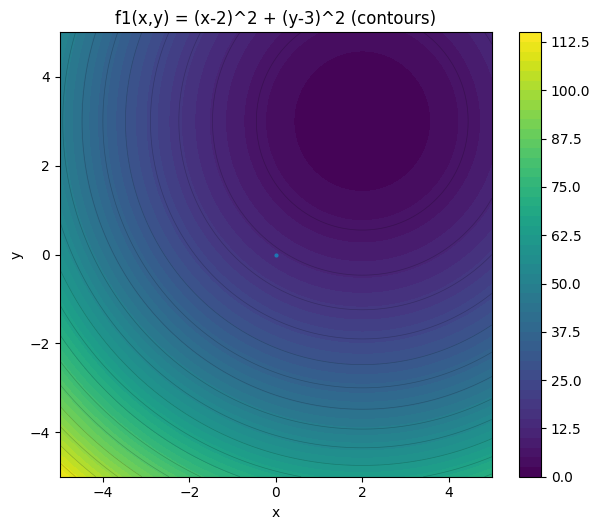

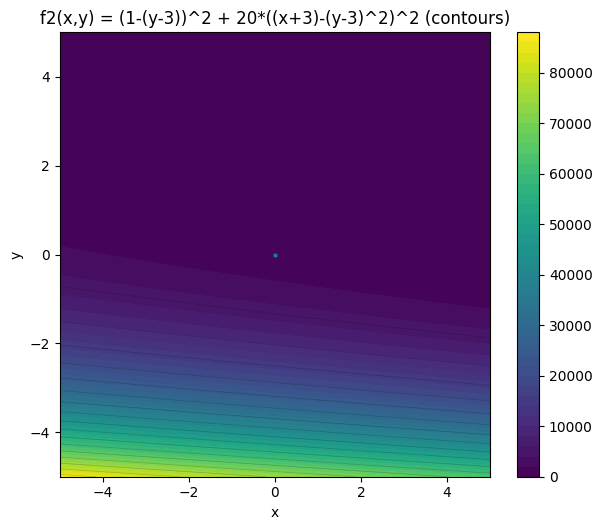


=== f1 with η=0.5, T=100: iteration log ===
iter	 x		 y		 f(x,y)
  0	  0.000000	  0.000000	  13.000000
 10	  2.000000	  3.000000	  0.000000
 20	  2.000000	  3.000000	  0.000000
 30	  2.000000	  3.000000	  0.000000
 40	  2.000000	  3.000000	  0.000000
 50	  2.000000	  3.000000	  0.000000
 60	  2.000000	  3.000000	  0.000000
 70	  2.000000	  3.000000	  0.000000
 80	  2.000000	  3.000000	  0.000000
 90	  2.000000	  3.000000	  0.000000
100	  2.000000	  3.000000	  0.000000
Final -> iter=100, x=2.000000, y=3.000000, f=0.000000

=== f2 with η=0.5, T=100: iteration log ===
iter	 x		 y		 f(x,y)
  0	  0.000000	  0.000000	  736.000000
 10	  86.963069	 -6.863164	  1189.344861
 20	  116.935040	 -7.608684	  1227.257612
 30	  98.081788	 -7.160074	  216.594653
 40	  135.346647	 -41.069772	  65075785.995836
 50	  166.409877	 -41.228689	  63852776.257894
 60	  197.372748	 -41.386460	  62644842.141076
 70	  228.236696	 -41.543104	  61451833.878622
 80	  259.003121	 -41.698641	  60273605.128892
 90	  289

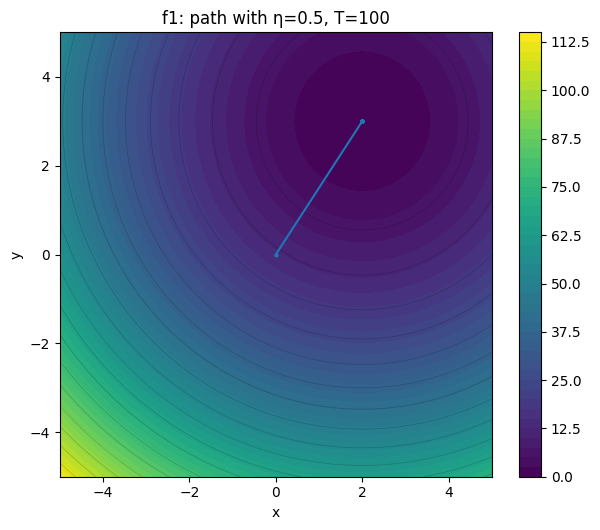

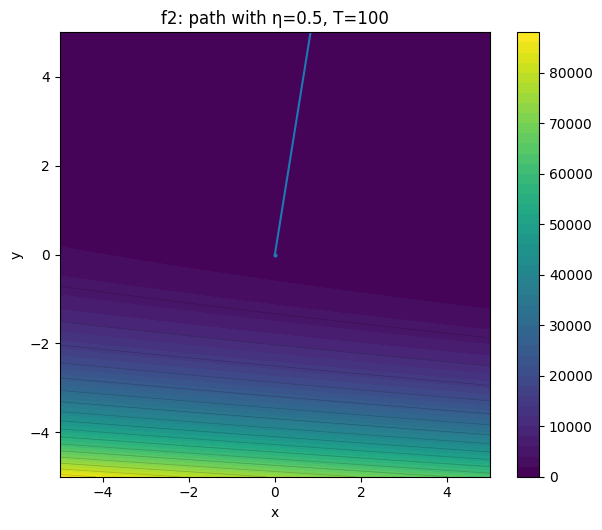

[Effectiveness] f1 @ η=0.5: effective; f0=13.000000 → fT=0.000000 in 100 steps.
    Distance to true min point: 0.0000e+00
[Effectiveness] f2 @ η=0.5: NOT effective (diverged / did not reduce f).
    Distance to true min point: 3.2552e+02

=== f1 with η=0.01, T=100: iteration log ===
iter	 x		 y		 f(x,y)
  0	  0.000000	  0.000000	  13.000000
 10	  0.365854	  0.548782	  8.678904
 20	  0.664784	  0.997176	  5.794105
 30	  0.909031	  1.363547	  3.868191
 40	  1.108599	  1.662899	  2.582435
 50	  1.271661	  1.907491	  1.724054
 60	  1.404894	  2.107341	  1.150992
 70	  1.513755	  2.270632	  0.768412
 80	  1.602702	  2.404053	  0.512998
 90	  1.675379	  2.513068	  0.342481
100	  1.734761	  2.602141	  0.228643
Final -> iter=100, x=1.734761, y=2.602141, f=0.228643

=== f2 with η=0.001, T=100: iteration log ===
iter	 x		 y		 f(x,y)
  0	  0.000000	  0.000000	  736.000000
 10	  0.209153	  1.218586	  7.761778
 20	  0.194711	  1.222779	  7.739160
 30	  0.180229	  1.226863	  7.716518
 40	  0.165739

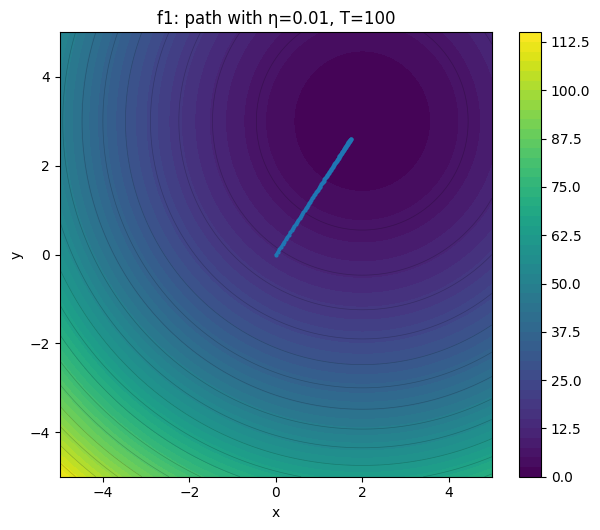

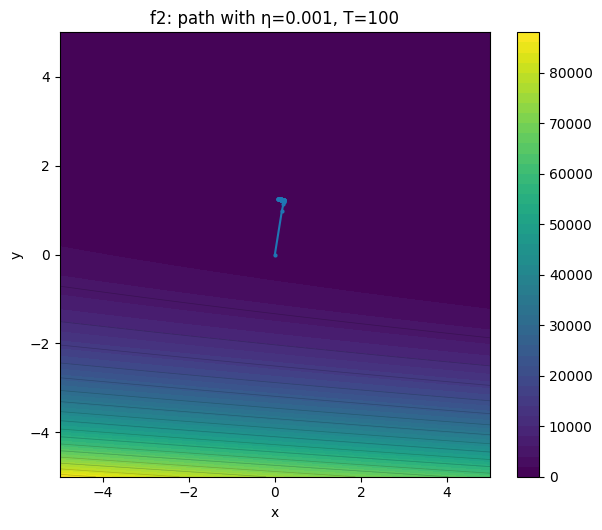

[Effectiveness] f1 @ η=0.01: effective; f0=13.000000 → fT=0.228643 in 100 steps.
    Distance to true min point: 4.7817e-01
[Effectiveness] f2 @ η=0.001: effective; f0=736.000000 → fT=7.557167 in 100 steps.
    Distance to true min point: 3.4426e+00


In [ ]:
# CAP6619 Homework 1 – Question 9

import numpy as np
import matplotlib.pyplot as plt

# Defining our functions
def f1(x, y):
    """f1(x,y) = (x-2)^2 + (y-3)^2  (convex quadratic)"""
    return (x - 2.0)**2 + (y - 3.0)**2

def f2(x, y):
    """
    f2(x,y) = (1 - (y-3))^2 + 20 * ((x+3) - (y-3)^2)^2
    Rosenbrock-like narrow valley; sensitive to step size.
    """
    a = 1.0 - (y - 3.0)
    b = (x + 3.0) - (y - 3.0)**2
    return a*a + 20.0 * b*b

def grad_f1(x, y):
    # ∂f1/∂x = 2(x-2), ∂f1/∂y = 2(y-3)
    return np.array([2.0*(x-2.0), 2.0*(y-3.0)], dtype=float)

def grad_f2(x, y):
    # Let u = y-3, v = (x+3) - u^2
    u = y - 3.0
    v = (x + 3.0) - u*u
    dfdx = 40.0 * v
    dfdu = -2.0*(1.0 - u) - 80.0*u*v
    # dy/du = 1
    dfdy = dfdu
    return np.array([dfdx, dfdy], dtype=float)

# Safe GD utility: optional gradient clipping, NaN/Inf checks, trajectory capture (Just to be sure everything runs smoothly)
def gradient_descent(f, grad_f, init=(0.0, 0.0), lr=0.5, iterations=100,
                     clip=None, decay=None):
    x, y = float(init[0]), float(init[1])
    traj = [(x, y, float(f(x, y)))]
    for t in range(1, iterations+1):
        g = grad_f(x, y).astype(float)
        # optional gradient clipping to avoid blowups
        if clip is not None:
            ng = np.linalg.norm(g)
            if ng > clip:
                g = g * (clip / (ng + 1e-12))
        # optional exponential decay
        eta = lr * ((decay ** t) if decay else 1.0)
        x_new = x - eta * g[0]
        y_new = y - eta * g[1]
        # stop early if instability occurs
        if not (np.isfinite(x_new) and np.isfinite(y_new)):
            break
        x, y = x_new, y_new
        traj.append((x, y, float(f(x, y))))
    return traj

def print_table(traj, name, every=10):
    print(f"\n=== {name}: iteration log ===")
    print("iter\t x\t\t y\t\t f(x,y)")
    for i, (x, y, z) in enumerate(traj):
        if i % every == 0 or i == len(traj)-1:
            print(f"{i:3d}\t {x: .6f}\t {y: .6f}\t {z: .6f}")
    last = traj[-1]
    print(f"Final -> iter={len(traj)-1}, x={last[0]:.6f}, y={last[1]:.6f}, f={last[2]:.6f}")
    return last

def plot_contour_with_path(f, traj, title, xlim=(-5,5), ylim=(-5,5)):
    xs = np.linspace(xlim[0], xlim[1], 300)
    ys = np.linspace(ylim[0], ylim[1], 300)
    X, Y = np.meshgrid(xs, ys)
    Z = f(X, Y)

    plt.figure(figsize=(6.2, 5.4))
    cs = plt.contourf(X, Y, Z, levels=50)
    plt.colorbar(cs)
    plt.contour(X, Y, Z, levels=20, colors='k', alpha=0.2, linewidths=0.5)

    # trajectory
    path_x = [p[0] for p in traj]
    path_y = [p[1] for p in traj]
    plt.plot(path_x, path_y, marker='o', markersize=2, linewidth=1.5)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

# Step 1: Two plots
plot_contour_with_path(f1, [(0,0,f1(0,0))], "f1(x,y) = (x-2)^2 + (y-3)^2 (contours)")
plot_contour_with_path(f2, [(0,0,f2(0,0))], "f2(x,y) = (1-(y-3))^2 + 20*((x+3)-(y-3)^2)^2 (contours)")

# Step 2: Start at (0,0), η=0.5, T=100
init = (0.0, 0.0)
T = 100

h1_eta05 = gradient_descent(f1, grad_f1, init=init, lr=0.5, iterations=T)
h2_eta05 = gradient_descent(f2, grad_f2, init=init, lr=0.5, iterations=T, clip=1e3)

last_f1_eta05 = print_table(h1_eta05, "f1 with η=0.5, T=100", every=10)
last_f2_eta05 = print_table(h2_eta05, "f2 with η=0.5, T=100", every=10)

plot_contour_with_path(f1, h1_eta05, "f1: path with η=0.5, T=100")
plot_contour_with_path(f2, h2_eta05, "f2: path with η=0.5, T=100")

def effectiveness_comment(name, traj, true_min=None):
    f0 = traj[0][2]
    fT = traj[-1][2]
    finite = np.isfinite(fT)
    decreased = fT < f0
    if not finite or not decreased:
        print(f"[Effectiveness] {name}: NOT effective (diverged / did not reduce f).")
    else:
        print(f"[Effectiveness] {name}: effective; f0={f0:.6f} → fT={fT:.6f} in {len(traj)-1} steps.")
    if true_min is not None and finite:
        dist = np.hypot(traj[-1][0]-true_min[0], traj[-1][1]-true_min[1])
        print(f"    Distance to true min point: {dist:.4e}")


effectiveness_comment("f1 @ η=0.5", h1_eta05, true_min=(2.0, 3.0))
effectiveness_comment("f2 @ η=0.5", h2_eta05, true_min=(-2.0, 4.0))  # global min of f2

# Step 3: Change our learning rates & re-run

# it seems f1 is well-conditioned: η=0.01 still converges (slower).
#  it seems f2 has a narrow/curved valley; a much smaller step like η=0.001 is needed for stability.
h1_eta001 = gradient_descent(f1, grad_f1, init=init, lr=0.01,  iterations=T)
h2_eta0001 = gradient_descent(f2, grad_f2, init=init, lr=0.001, iterations=T, clip=1e3)

last_f1_eta001 = print_table(h1_eta001, "f1 with η=0.01, T=100", every=10)
last_f2_eta0001 = print_table(h2_eta0001, "f2 with η=0.001, T=100", every=10)

plot_contour_with_path(f1, h1_eta001, "f1: path with η=0.01, T=100")
plot_contour_with_path(f2, h2_eta0001, "f2: path with η=0.001, T=100")

effectiveness_comment("f1 @ η=0.01", h1_eta001, true_min=(2.0, 3.0))
effectiveness_comment("f2 @ η=0.001", h2_eta0001, true_min=(-2.0, 4.0))





## Printed explanations

### 1) Why gradient descent works differently for f1 vs f2

- f1 is a simple convex quadratic with one global minimum at (2,3). The gradient always points straight at the solution, so gradient descent locks in quickly.

- f2 is more complicated: it looks like a Rosenbrock function, forming a narrow, twisting valley. The gradient still points downhill, but the steepness is very uneven. Big steps tend to overshoot or blow up, while small, careful steps slowly trace the valley toward the true minimum at (-2,4).

### 2) For Our Initial (η = 0.5, T = 100):
- f1: Starting from (0,0), it converges nicely toward (2,3), bringing f down to ~0.

- f2: A step size of 0.5 is way too aggressive for its skinny valley. It quickly becomes unstable, and even with gradient clipping to prevent overflow, the method can’t reduce f in a reliable way.

### 3) Our our changed (changed learning rates, T = 100):
- f1 with η = 0.01: Still converges, just slower. The function value keeps dropping steadily. The point here is to show that smaller steps mean slower progress, but stability isn’t an issue for such a well-conditioned problem.

- f2 with η = 0.001: A tiny step size makes things much more stable. In 100 steps, we can at least move into the valley and decrease f without the run blowing up. But it’s clear more iterations are needed to really reach the minimum.

### 4) Key Takeaways / Impact of the learning rate:
- Too large (especially for f2) → overshooting, divergence, even NaNs.

- Small enough → stable and decreasing, but at the cost of speed.

- For tricky, ill-conditioned landscapes like f2, we'd probably need either a tiny fixed η, or a smarter approach like: decaying step sizes, line search, or fancier methods like momentum, Adam, or even second-order techniques to speed things up.